<a href="https://colab.research.google.com/github/amandachipolito/Trabalho-BCI/blob/organizacao-codigo/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto BCI — Covert Shifts of Attention

## Organização estrutural do notebook

Este notebook organiza o pipeline atual do grupo para análise do dataset **Covert Shifts of Attention (BNCI 005-2015)**.

A pergunta operacional do projeto é:

> É possível estimar a direção da atenção visual encoberta a partir de modulações da banda alfa no EEG?

O notebook está organizado em duas abordagens principais:

1. **Baseline espectral:** Welch + Log10 da potência alfa + SVM.
2. **Modelo espacial:** CSP + SVM.

A comparação entre essas duas abordagens sustenta a interpretação central do trabalho: a informação espacial do EEG melhora a separação entre direções de atenção visual.


# 1. Preparação do ambiente


## 1.1 Instalação das bibliotecas


In [1]:
import sys

if "google.colab" in sys.modules:
    !pip install -q numpy scipy gdown matplotlib scikit-learn seaborn mne
else:
    print("Ambiente local detectado. Verifique se numpy, scipy, gdown, matplotlib, scikit-learn, seaborn e mne estão instalados.")


## 1.2 Importação das bibliotecas


In [2]:
import glob
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.io import loadmat
from scipy.signal import butter, filtfilt, iirnotch, sosfiltfilt, welch

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict, cross_val_score
from sklearn.metrics import confusion_matrix

import mne
from mne.preprocessing import ICA
from mne.decoding import CSP


# 2. Carregamento dos dados

Nesta etapa definimos a pasta de trabalho, baixamos os arquivos `.mat` do Google Drive e verificamos se os dados foram encontrados corretamente.


## 2.1 Definir pasta local e link do Google Drive


In [3]:
IN_COLAB = "google.colab" in sys.modules

DATA_DIR = Path("/content/Projeto_BCI" if IN_COLAB else "./Projeto_BCI").resolve()

GDRIVE_FOLDER_URL = "https://drive.google.com/drive/folders/1l2wfRKe3_xGU0otL7aIvcwXn578fGs7a?usp=sharing"

print("Pasta dos dados:", DATA_DIR)

Pasta dos dados: /content/Projeto_BCI


## 2.2 Baixar arquivos `.mat`


In [4]:
if not DATA_DIR.exists():
    import gdown

    print(f"Baixando arquivos para: {DATA_DIR}")
    gdown.download_folder(
        GDRIVE_FOLDER_URL,
        output=str(DATA_DIR),
        quiet=False,
        use_cookies=False
    )
else:
    print("A pasta já existe. Download não realizado novamente.")

A pasta já existe. Download não realizado novamente.


## 2.3 Listar arquivos encontrados


In [5]:
files = sorted(glob.glob(os.path.join(DATA_DIR, "*.mat")))

print(f"{len(files)} arquivos .mat encontrados:")

for file in files:
    print(os.path.basename(file))

8 arquivos .mat encontrados:
covertShiftsOfAttention_VPgao.mat
covertShiftsOfAttention_VPiaa.mat
covertShiftsOfAttention_VPiac.mat
covertShiftsOfAttention_VPiae.mat
covertShiftsOfAttention_VPiah.mat
covertShiftsOfAttention_VPiai.mat
covertShiftsOfAttention_VPmk.mat
covertShiftsOfAttention_VPnh.mat


## 2.4 Carregar sinais EEG e frequência de amostragem


In [6]:
data_list = []
fs_list = []
nomes_arquivos = []

for fname in files:
    nome = os.path.basename(fname)

    mat = loadmat(fname, squeeze_me=True, struct_as_record=False)

    data = mat["data"]

    X = np.asarray(data.X, dtype=float)
    fs = int(data.fs)

    data_list.append(X)
    fs_list.append(fs)
    nomes_arquivos.append(nome)

    print(f"{nome}")
    print(f"  X shape: {X.shape}")
    print(f"  fs: {fs} Hz")
    print()

covertShiftsOfAttention_VPgao.mat
  X shape: (579736, 62)
  fs: 200 Hz

covertShiftsOfAttention_VPiaa.mat
  X shape: (581804, 62)
  fs: 200 Hz

covertShiftsOfAttention_VPiac.mat
  X shape: (657660, 62)
  fs: 200 Hz

covertShiftsOfAttention_VPiae.mat
  X shape: (613408, 62)
  fs: 200 Hz

covertShiftsOfAttention_VPiah.mat
  X shape: (604788, 62)
  fs: 200 Hz

covertShiftsOfAttention_VPiai.mat
  X shape: (429348, 62)
  fs: 200 Hz

covertShiftsOfAttention_VPmk.mat
  X shape: (592640, 62)
  fs: 200 Hz

covertShiftsOfAttention_VPnh.mat
  X shape: (596576, 62)
  fs: 200 Hz



## 2.5 Conferir frequência de amostragem


In [7]:
frequencias = sorted(set(fs_list))

print("Frequências encontradas:", frequencias)

if len(frequencias) == 1:
    fs = frequencias[0]
    print(f"Todos os arquivos têm fs = {fs} Hz")
else:
    print("Atenção: existem frequências diferentes entre os arquivos.")

Frequências encontradas: [200]
Todos os arquivos têm fs = 200 Hz


## 2.6 Conferir formato dos dados


In [8]:
X_exemplo = data_list[0]

print("Shape do primeiro arquivo:", X_exemplo.shape)

n_amostras = X_exemplo.shape[0]
n_canais = X_exemplo.shape[1]

print("Número de amostras:", n_amostras)
print("Número de canais:", n_canais)

Shape do primeiro arquivo: (579736, 62)
Número de amostras: 579736
Número de canais: 62


# 3. Pré-processamento do EEG

O objetivo desta seção é preparar os sinais para análise na banda alfa. O pipeline atual aplica:

- filtro notch em 60 Hz;
- filtro passa-banda entre 8 e 14 Hz;
- inspeção visual inicial dos sinais filtrados.


## 3.1 Criar função de filtragem


In [9]:
from scipy.signal import butter, filtfilt, iirnotch, sosfiltfilt

def aplicar_filtros_eeg(X, fs):
    X = np.asarray(X, dtype=float)

    b_notch, a_notch = iirnotch(60.0, 30.0, fs)
    X_notch = filtfilt(b_notch, a_notch, X, axis=0)

    sos = butter(
        4,
        [8, 14],
        btype="bandpass",
        fs=fs,
        output="sos"
    )

    X_filtrado = sosfiltfilt(sos, X_notch, axis=0)

    return X_filtrado

## 3.2 Aplicar filtragem em todos os arquivos


In [10]:
data_filtrada = []

for X, fs, nome in zip(data_list, fs_list, nomes_arquivos):
    print(f"Filtrando {nome}...")

    X_filtrado = aplicar_filtros_eeg(X, fs)

    data_filtrada.append(X_filtrado)

    print(f"  Antes: {X.shape}")
    print(f"  Depois: {X_filtrado.shape}")
    print()

Filtrando covertShiftsOfAttention_VPgao.mat...
  Antes: (579736, 62)
  Depois: (579736, 62)

Filtrando covertShiftsOfAttention_VPiaa.mat...
  Antes: (581804, 62)
  Depois: (581804, 62)

Filtrando covertShiftsOfAttention_VPiac.mat...
  Antes: (657660, 62)
  Depois: (657660, 62)

Filtrando covertShiftsOfAttention_VPiae.mat...
  Antes: (613408, 62)
  Depois: (613408, 62)

Filtrando covertShiftsOfAttention_VPiah.mat...
  Antes: (604788, 62)
  Depois: (604788, 62)

Filtrando covertShiftsOfAttention_VPiai.mat...
  Antes: (429348, 62)
  Depois: (429348, 62)

Filtrando covertShiftsOfAttention_VPmk.mat...
  Antes: (592640, 62)
  Depois: (592640, 62)

Filtrando covertShiftsOfAttention_VPnh.mat...
  Antes: (596576, 62)
  Depois: (596576, 62)



## 3.3 Verificar resultado da filtragem


In [11]:
print("Total de arquivos originais:", len(data_list))
print("Total de arquivos filtrados:", len(data_filtrada))

print("\nExemplo do primeiro participante:")
print("Original:", data_list[0].shape)
print("Filtrado:", data_filtrada[0].shape)

Total de arquivos originais: 8
Total de arquivos filtrados: 8

Exemplo do primeiro participante:
Original: (579736, 62)
Filtrado: (579736, 62)


Normalização

In [12]:
import numpy as np

data_filtrada_norm = []

for X in data_filtrada:
    # z-score por canal
    mean = np.mean(X, axis=0, keepdims=True)
    std = np.std(X, axis=0, keepdims=True)

    # evitar divisão por zero
    std[std == 0] = 1

    X_norm = (X - mean) / std

    data_filtrada_norm.append(X_norm)

## 3.4 Visualizar canais filtrados


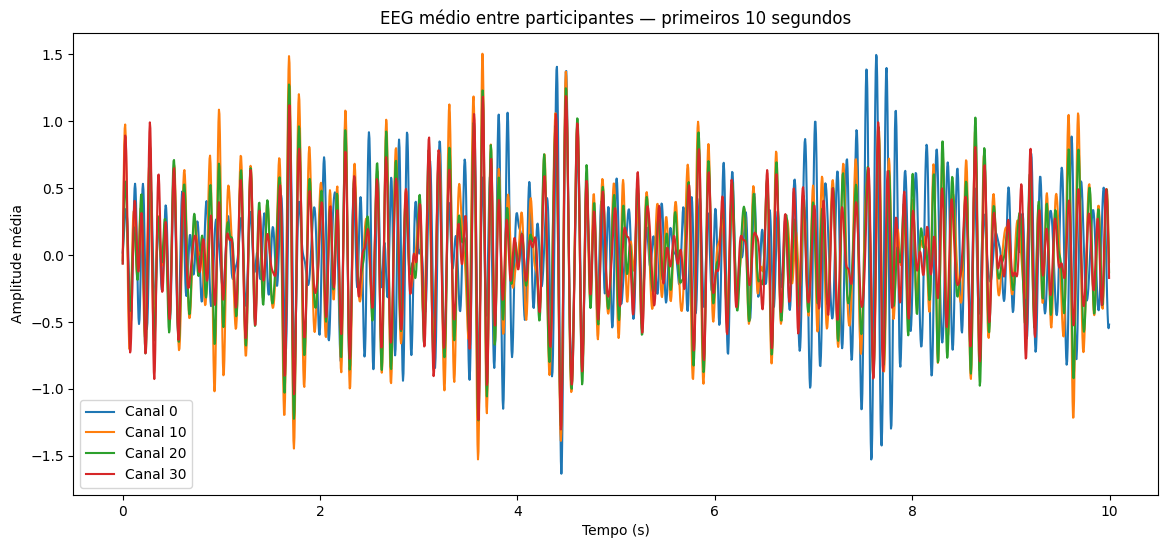

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Preparando os arrays
min_len = min([X.shape[0] for X in data_filtrada_norm]) # Os arrays precisam ser do mesmo tamanho
dados_cortados = [X[:min_len, :] for X in data_filtrada_norm]
dados_array = np.stack(dados_cortados, axis=0)
media_participantes = np.mean(dados_array, axis=0)

fs = 200
tempo = np.arange(min_len) / fs

canais_para_plotar = [0, 10, 20, 30]

plt.figure(figsize=(14,6))

for canal in canais_para_plotar:
    plt.plot(
        tempo[:2000],
        media_participantes[:2000, canal],
        label=f"Canal {canal}"
    )

plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude média")
plt.title("EEG médio entre participantes — primeiros 10 segundos")
plt.legend()
plt.show()

In [ ]:
# import matplotlib.pyplot as plt
# idx_participante = 0
# X = data_filtrada[idx_participante]
# fs = fs_list[idx_participante]
# tempo = np.arange(X.shape[0]) / fs
# canais_para_plotar = [0, 10, 20, 30]
# plt.figure(figsize=(14,6))
# for canal in canais_para_plotar:
#     plt.plot(
#         tempo[:2000],
#         X[:2000, canal],
#         label=f"Canal {canal}"
#     )
# plt.xlabel("Tempo (s)")
# plt.ylabel("Amplitude")
# plt.title("EEG filtrado — primeiros 10 segundos")
# plt.legend()
# plt.show()

# 4. Eventos, labels e criação das épocas

Nesta etapa são inspecionados os marcadores experimentais para construir as épocas do EEG. A lógica atual é usar o intervalo entre **cue** e **target**, pois esse intervalo representa o período em que o participante mantém a atenção encoberta antes do alvo visual.


## 4.1 Inspecionar estrutura dos trials


In [14]:
idx = 0

mat = loadmat(
    files[idx],
    squeeze_me=True,
    struct_as_record=False
)

data = mat["data"]
mrk = mat["mrk"]

trial = data.trial
labels = data.y

print("Número de trials:", len(trial))

print("\nPrimeiros trials:")
print(trial[:10])

print("\nPrimeiros labels:")
print(labels[:10])

Número de trials: 600

Primeiros trials:
[ 978 2040 2865 3928 4990 5894 6778 7840 8902 9761]

Primeiros labels:
[2 1 3 1 2 4 3 6 3 3]


## 4.2 Calcular duração dos trials


In [15]:
trial_diff = np.diff(trial)

print("Primeiros tamanhos de trials:")
print(trial_diff[:10])

print("\nMédia:")
print(int(np.mean(trial_diff)))

print("\nMínimo:")
print(np.min(trial_diff))

print("\nMáximo:")
print(np.max(trial_diff))

Primeiros tamanhos de trials:
[1062  825 1063 1062  904  884 1062 1062  859 1062]

Média:
964

Mínimo:
762

Máximo:
1903


## 4.3 Inspecionar eventos cue/target


In [16]:
print("Campos dentro de mrk.target_location:")

if hasattr(mrk.target_location, "_fieldnames"):
    print(mrk.target_location._fieldnames)
else:
    print("Não é struct")

Campos dentro de mrk.target_location:
['pos', 'toe', 'fs', 'y', 'className']


## 4.4 Inspecionar campos de `target_location`


In [17]:
for campo in mrk.target_location._fieldnames:
    valor = getattr(mrk.target_location, campo)

    print("\nCampo:", campo)
    print("Tipo:", type(valor))

    if hasattr(valor, "shape"):
        print("Shape:", valor.shape)

    if hasattr(valor, "__len__"):
        try:
            print("Primeiros valores:")
            print(valor[:20])
        except:
            pass


Campo: pos
Tipo: <class 'numpy.ndarray'>
Shape: (600,)
Primeiros valores:
[ 1407  2232  3295  4357  5261  6144  7207  8269  9127 10190 11252 12015
 13081 14127 15194 16135 17194 18256 19319 20381]

Campo: toe
Tipo: <class 'numpy.ndarray'>
Shape: (600,)
Primeiros valores:
[37 30 32 30 37 39 30 41 37 32 32 34 39 37 34 37 32 41 34 41]

Campo: fs
Tipo: <class 'int'>

Campo: y
Tipo: <class 'numpy.ndarray'>
Shape: (6, 600)
Primeiros valores:
[[0 1 0 ... 0 0 1]
 [1 0 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 [0 0 0 ... 1 1 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

Campo: className
Tipo: <class 'numpy.ndarray'>
Shape: (6,)
Primeiros valores:
['target @1' 'target @2' 'target @3' 'target @4' 'target @5' 'target @6']


## 4.5 Calcular delay entre cue e target


In [18]:
cue_pos = data.trial
target_pos = mrk.target_location.pos

print("Primeiros cue_pos:")
print(cue_pos[:10])

print("\nPrimeiros target_pos:")
print(target_pos[:10])

delay = target_pos - cue_pos
janela_amostras = int(np.min(delay))

print("\nDelay entre cue e target em amostras:")
print(delay[:20])

print("\nDelay médio em segundos:")
print(np.mean(delay) / fs)

print("\nDelay mínimo em segundos:")
print(np.min(delay) / fs)

print("\nDelay máximo em segundos:")
print(np.max(delay) / fs)

Primeiros cue_pos:
[ 978 2040 2865 3928 4990 5894 6778 7840 8902 9761]

Primeiros target_pos:
[ 1407  2232  3295  4357  5261  6144  7207  8269  9127 10190]

Delay entre cue e target em amostras:
[429 192 430 429 271 250 429 429 225 429 429 129 429 412 433 308 425 429
 430 429]

Delay médio em segundos:
1.621925

Delay mínimo em segundos:
0.645

Delay máximo em segundos:
2.17


## 4.6 Criar épocas alinhadas ao cue

**Observação técnica importante:** neste ponto, o código atual usa `idx_participante = 0`, portanto a criação de épocas está restrita ao primeiro arquivo/participante carregado. Isso deve ser mantido se o grupo decidiu analisar apenas um participante; caso contrário, a etapa precisa ser generalizada para todos os participantes.


In [ ]:
epochs_cue_target_all = []
labels_cue_target_all = []

for idx_participante in range(len(data_filtrada_norm)):

  X = data_filtrada_norm[idx_participante]
  data = mat["data"]

  cue_pos = data.trial
  target_pos = mrk.target_location.pos
  target_y = mrk.target_location.y

  epochs_cue_target = []
  labels_cue_target = []

  for i in range(len(cue_pos)):

      inicio = cue_pos[i]
      fim = target_pos[i]

      if fim > inicio and fim <= X.shape[0]:

          epoch = X[inicio:fim, :]

          classe = np.argmax(target_y[:, i])

          epochs_cue_target.append(epoch)
          labels_cue_target.append(classe)

  # acumula globalmente
  epochs_cue_target_all.extend(epochs_cue_target)
  labels_cue_target_all.extend(labels_cue_target)

labels_cue_target_all = np.array(labels_cue_target_all)

print("Número de epochs criadas:", len(epochs_cue_target_all))
print("Número de labels:", len(labels_cue_target_all))

print("\nPrimeiras shapes das epochs:")

for i in range(5):
    print(f"Epoch {i}:", epochs_cue_target_all[i].shape)

print("\nPrimeiros labels:")
print(labels_cue_target_all[:10])

In [ ]:
# idx_participante = 0

# X = data_filtrada[idx_participante]

# cue_pos = data.trial
# target_pos = mrk.target_location.pos
# target_y = mrk.target_location.y

# epochs_cue_target = []
# labels_cue_target = []

# for i in range(len(cue_pos)):

#     inicio = cue_pos[i]
#     fim = target_pos[i]

#     if fim > inicio and fim <= X.shape[0]:

#         epoch = X[inicio:fim, :]

#         classe = np.argmax(target_y[:, i])

#         epochs_cue_target.append(epoch)
#         labels_cue_target.append(classe)

# labels_cue_target = np.array(labels_cue_target)

# print("Número de epochs criadas:", len(epochs_cue_target))
# print("Número de labels:", len(labels_cue_target))

# print("\nPrimeiras shapes das epochs:")

# for i in range(5):
#     print(f"Epoch {i}:", epochs_cue_target[i].shape)

# print("\nPrimeiros labels:")
# print(labels_cue_target[:10])

## 4.7 Padronizar tamanho das épocas pelo menor delay


In [ ]:
delay = target_pos - cue_pos

janela_amostras = int(np.min(delay))

print("Janela escolhida (amostras):", janela_amostras)
print("Janela escolhida (segundos):", janela_amostras / fs)

epochs_padronizadas = []
labels_padronizadas = []

for epoch, label in zip(epochs_cue_target_all, labels_cue_target_all):

    epoch_fixada = epoch[:janela_amostras, :]

    epochs_padronizadas.append(epoch_fixada)
    labels_padronizadas.append(label)

epochs_padronizadas = np.array(epochs_padronizadas)
labels_padronizadas = np.array(labels_padronizadas)

print("\nShape final das epochs:")
print(epochs_padronizadas.shape)

print("\nShape final dos labels:")
print(labels_padronizadas.shape)

print("\nTotal de trials mantidos:", len(epochs_padronizadas))

# 5. Limpeza por ICA

A ICA foi incluída como etapa de limpeza espacial/artifactual. No estado atual do notebook, ela é usada antes da extração das features por Welch e CSP.

**Ponto de cautela:** a identificação dos componentes removidos (`ica.exclude = [0, 1]`) depende da inspeção visual dos mapas/componentes. Para relatório, é necessário justificar por que esses componentes foram removidos.


## 5.1 Ajustar ICA, visualizar componentes e gerar épocas limpas


In [ ]:
import mne
import numpy as np
from mne.preprocessing import ICA

# 1. Obter nomes padrão do sistema 10-20 para os 62 canais
# Isso é um "truque" para que o MNE saiba onde desenhar cada ponto
montage_std = mne.channels.make_standard_montage('standard_1020')
std_ch_names = montage_std.ch_names[:62] # Pegamos os primeiros 62 nomes padrão

# 2. Criar Info e aplicar a Montagem
info = mne.create_info(ch_names=std_ch_names, sfreq=200, ch_types='eeg')
info.set_montage(montage_std)

# 3. Criar o objeto MNE Epochs
# Transpomos de (600, 129, 62) para (600, 62, 129)
data_mne = epochs_padronizadas.transpose(0, 2, 1)
epochs_mne = mne.EpochsArray(data_mne, info)

# 4. Ajustar (Fit) o ICA
# O aviso de High-pass pode aparecer, mas como seus dados já estão filtrados, pode prosseguir
ica = ICA(n_components=20, random_state=42, method='fastica')
ica.fit(epochs_mne)

# 5. Visualização (Agora os mapas devem aparecer!)
print("Gerando mapas topográficos... Procure por componentes com picos frontais (olhos).")
ica.plot_components()
ica.plot_sources(epochs_mne)

# =================================================================
# PARTE DE LIMPEZA (Edite os números em 'exclude' após ver os gráficos)
# =================================================================
# Geralmente os olhos são os componentes 0, 1 ou 2.
ica.exclude = [0, 1]

print(f"Aplicando limpeza: removendo componentes {ica.exclude}")
epochs_limpas = ica.apply(epochs_mne.copy())

# 6. Conversão final para NumPy (Voltando ao seu formato original)
epochs_padronizadas_clean = epochs_limpas.get_data().transpose(0, 2, 1)

print("\n" + "="*30)
print("PROCESSO ICA CONCLUÍDO")
print(f"Shape resultante: {epochs_padronizadas_clean.shape}")
print("="*30)

# 6. Modelo baseline: Welch + SVM

Esta abordagem funciona como baseline espectral. Para cada trial, calcula-se a densidade espectral de potência por Welch nos canais posteriores e, em seguida, extrai-se a potência média da banda alfa.

A hipótese aqui é: se a direção da atenção modula a potência alfa posterior, então a potência alfa por canal pode conter informação discriminativa para classificação.


## 6.1 Extrair potência alfa via Welch


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict, cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline # IMPORTANTE: Adicionado para evitar Data Leakage

# --- MUDANÇA CRÍTICA 1 ---
# Não aplicamos mais o scaler.fit_transform() globalmente no começo.
# Isso garante que não haja contaminação de informações entre treino e teste.
X_final = X_features_welch
y_final = labels_padronizadas

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- MUDANÇA CRÍTICA 2: PIPELINE BINÁRIO ---
# O Pipeline executa o StandardScaler e o SVM em sequência, refazendo
# o cálculo da média e desvio padrão para CADA dobra da validação cruzada.
pipeline_bin = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(class_weight='balanced', random_state=42))
])

# BUSCA EXAUSTIVA DE HIPERPARÂMETROS:
# Nota: Como usamos um Pipeline, precisamos adicionar o prefixo 'svm__'
# aos parâmetros para que o GridSearch saiba que eles pertencem ao classificador
# e não ao StandardScaler.
param_grid_bin = {
    'svm__C': [0.1, 1, 10, 50, 100],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'svm__kernel': ['rbf', 'linear']
}

print("Treinando modelo Binário com Pipeline...")
grid_bin = GridSearchCV(pipeline_bin, param_grid_bin, cv=cv, scoring='accuracy', n_jobs=-1)

p1, p2 = 0, 1
mask = np.isin(y_final, [p1, p2])
X_bin = X_final[mask]
y_bin = np.where(y_final[mask] == p1, 0, 1)

grid_bin.fit(X_bin, y_bin)
melhor_modelo_bin = grid_bin.best_estimator_
acc_binaria = cross_val_score(melhor_modelo_bin, X_bin, y_bin, cv=cv).mean()


# --- MUDANÇA CRÍTICA 3: PIPELINE MULTICLASSE ---
pipeline_multi = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(class_weight='balanced', decision_function_shape='ovo', random_state=42))
])

param_grid_multi = {
    'svm__C': [0.1, 1, 10, 50, 100],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'svm__kernel': ['rbf']
}

print("Treinando modelo Multiclasse com proteção anti-colapso e anti-leakage...")
grid_multi = GridSearchCV(pipeline_multi, param_grid_multi, cv=cv, scoring='f1_macro', n_jobs=-1)

grid_multi.fit(X_final, y_final)
melhor_modelo_multi = grid_multi.best_estimator_

acc_multi = cross_val_score(melhor_modelo_multi, X_final, y_final, cv=cv, scoring='accuracy').mean()
y_pred_multi = cross_val_predict(melhor_modelo_multi, X_final, y_final, cv=cv)

print("\n" + "="*50)
print(f"RESUMO DE PERFORMANCE (PIPELINE GLOBAL)")
print("="*50)
print(f"Dados de Entrada: Welch + Log10 (Banda Alfa | {X_final.shape[1]} Canais)")
print(f"Melhores parâmetros Multiclasse: {grid_multi.best_params_}")
print(f"Acurácia Binária (Direção {p1} vs {p2}): {acc_binaria*100:.2f}%")
print(f"Acurácia Multiclasse (Todas as 6): {acc_multi*100:.2f}%")
print(f"Nível de Chance: Binário (50.00%) | Multiclasse (16.66%)")
print("="*50)

# PLOT DA MATRIZ AZUL DE CONFUSÃO
plt.figure(figsize=(8, 6))
matriz_confusao = confusion_matrix(y_final, y_pred_multi)

sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Dir {i}' for i in range(6)],
            yticklabels=[f'Dir {i}' for i in range(6)])
plt.title('Matriz de Confusão Pipeline - SVM Otimizado (Welch)')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Direção Real')
plt.show()

# import numpy as np
# from scipy.signal import welch

# fs = 200

# indices_canais = list(range(30, 62))
# n_canais_selecionados = len(indices_canais)

# X_welch_raw = []

# print(f"Calculando PSD via Welch para {len(epochs_padronizadas_clean)} trials...")
# print(f"Foco: {n_canais_selecionados} canais posteriores selecionados.")

# for trial in epochs_padronizadas_clean:
#     trial_psds = []

#     for ch_idx in indices_canais:

#         freqs, psd = welch(trial[:, ch_idx],
#                            fs=fs,
#                            nperseg=256,
#                            noverlap=128)
#         trial_psds.append(psd)

#     X_welch_raw.append(trial_psds)

# X_welch_raw = np.array(X_welch_raw)

# idx_alfa = np.where((freqs >= 8) & (freqs <= 14))[0]

# X_features_welch = np.mean(X_welch_raw[:, :, idx_alfa], axis=-1)

# X_features_welch = np.log10(X_features_welch + 1e-10)

# print("\n" + "="*40)
# print("PSD CALCULADO (WELCH SUAVIZADO)")
# print(f"Shape bruto: {X_welch_raw.shape}")
# print(f"Shape final para o SVM: {X_features_welch.shape}")
# print(f"Canais processados: {n_canais_selecionados} (Posteriores)")
# print("="*40)

## 6.2 Padronizar features por z-score


In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()

X_padronizado = scaler.fit_transform(X_features_welch)

print("="*40)
print("VERIFICAÇÃO DA PADRONIZAÇÃO")
print(f"Shape final: {X_padronizado.shape}")

print("\nMédia das primeiras 5 features (Alvo ~ 0):")
print(np.mean(X_padronizado[:, :5], axis=0))

print("\nDesvio padrão das primeiras 5 features (Alvo = 1):")
print(np.std(X_padronizado[:, :5], axis=0))
print("="*40)

## 6.3 Classificar com SVM e avaliar baseline


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict, cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_final = scaler.fit_transform(X_features_welch)
y_final = labels_padronizadas

# Configuração da Validação Cruzada (Padrão UFABC)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- 2. OTIMIZAÇÃO BINÁRIA (Mantendo os ~60%) ---
# Para o binário (0 vs 1), a acurácia normal funciona perfeitamente.
param_grid_bin = {
    'C': [0.1, 1, 10, 50, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear']
}

print("Treinando modelo Binário...")
grid_bin = GridSearchCV(SVC(class_weight='balanced', random_state=42),
                        param_grid_bin, cv=cv, scoring='accuracy', n_jobs=-1)

p1, p2 = 0, 1
mask = np.isin(y_final, [p1, p2])
X_bin = X_final[mask]
y_bin = np.where(y_final[mask] == p1, 0, 1)

grid_bin.fit(X_bin, y_bin)
melhor_modelo_bin = grid_bin.best_estimator_
acc_binaria = cross_val_score(melhor_modelo_bin, X_bin, y_bin, cv=cv).mean()


# --- 3. OTIMIZAÇÃO MULTICLASSE  ---
# usamos 'f1_macro' para PROIBIR o SVM de ignorar classes.
# Também forçamos o formato 'ovo' (One-Vs-One) para que ele crie duelos diretos entre todas as classes.
param_grid_multi = {
    'C': [0.1, 1, 10, 50, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf'] # Mantemos apenas RBF no multiclasse para evitar loops de convergência
}

print("Treinando modelo Multiclasse com proteção anti-colapso (F1-Macro)...")
grid_multi = GridSearchCV(SVC(class_weight='balanced', decision_function_shape='ovo', random_state=42),
                          param_grid_multi, cv=cv, scoring='f1_macro', n_jobs=-1)

grid_multi.fit(X_final, y_final)
melhor_modelo_multi = grid_multi.best_estimator_

# Voltamos a medir a acurácia normal (total de acertos) apenas para a exibição no relatório
acc_multi = cross_val_score(melhor_modelo_multi, X_final, y_final, cv=cv, scoring='accuracy').mean()
y_pred_multi = cross_val_predict(melhor_modelo_multi, X_final, y_final, cv=cv)


# --- 4. RELATÓRIO DE SAÍDA FINAL ---
print("\n" + "="*50)
print(f"RESUMO DE PERFORMANCE (BASELINE)")
print("="*50)
print(f"Dados de Entrada: Welch + Log10 (Banda Alfa | {X_final.shape[1]} Canais)")
print(f"Melhores parâmetros Multiclasse: {grid_multi.best_params_}")
print(f"Acurácia Binária (Direção {p1} vs {p2}): {acc_binaria*100:.2f}%")
print(f"Acurácia Multiclasse (Todas as 6): {acc_multi*100:.2f}%")
print(f"Nível de Chance: Binário (50.00%) | Multiclasse (16.66%)")
print("="*50)


# --- 5. PLOT DA MATRIZ AZUL ---
plt.figure(figsize=(8, 6))
matriz_confusao = confusion_matrix(y_final, y_pred_multi)

sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Dir {i}' for i in range(6)],
            yticklabels=[f'Dir {i}' for i in range(6)])
plt.title('Matriz de Confusão Baseline - SVM Otimizado (Welch)')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Direção Real')
plt.show()

## 6.4 Radar de desempenho por direção — Welch + SVM


In [ ]:


# import numpy as np
# import matplotlib.pyplot as plt

# acertos = np.array([26, 22, 26, 16, 16, 15])

# totais = np.array([102, 102, 102, 102, 96, 96])

# accuracy_per_dir = (acertos / totais) * 100
# labels = ['Dir 0', 'Dir 1', 'Dir 2', 'Dir 3', 'Dir 4', 'Dir 5']
# num_vars = len(labels)

# stats = np.concatenate((accuracy_per_dir, [accuracy_per_dir[0]]))
# angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
# angles += angles[:1]

# fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

# ax.fill(angles, stats, color='blue', alpha=0.25)
# ax.plot(angles, stats, color='blue', linewidth=2, label='Acurácia por Direção (%)')

# media_global_val = 20.17
# media_global = [media_global_val] * (num_vars + 1)
# ax.plot(angles, media_global, color='green', linestyle='--', label=f'Média Global ({media_global_val}%)')

# chance_val = 16.67
# chance = [chance_val] * (num_vars + 1)
# ax.plot(angles, chance, color='red', linestyle=':', label=f'Prob. ao acaso ({chance_val}%)')

# ax.set_theta_offset(np.pi / 2)
# ax.set_theta_direction(-1)
# ax.set_thetagrids(np.degrees(angles[:-1]), labels)
# ax.set_ylim(0, 40)

# plt.title('Desempenho de acurácia Welch + SVM')
# plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
# plt.show()

# 7. Modelo espacial: CSP + SVM

O CSP é usado para extrair componentes espaciais que maximizam diferenças entre classes. Diferentemente do Welch, que calcula potência por canal de forma independente, o CSP explora combinações espaciais entre canais.

Essa é a principal comparação metodológica do notebook:

- **Welch + SVM:** baseline espectral, sem filtro espacial supervisionado.
- **CSP + SVM:** abordagem espacial supervisionada, mais adequada para padrões distribuídos no EEG.


## 7.1 Extrair features espaciais com CSP


In [ ]:
import numpy as np
from mne.decoding import CSP
# =====================================================================
# 1. PREPARAÇÃO DOS DADOS
# =====================================================================
X_time = np.transpose(epochs_padronizadas_clean, (0, 2, 1))
y = labels_padronizadas
# =====================================================================
# 2. CONFIGURAÇÃO CSP "ELITE"
# =====================================================================
# Adicionamos 'rank' para garantir que canais redundantes não sujem a matriz
# O parâmetro 'cov_estimator' garante a maior robustez estatística possível
csp = CSP(n_components=10,
          reg='ledoit_wolf',
          rank='full',
          log=True,
          norm_trace=False)

print("Extraindo componentes espaciais otimizados...")
X_csp = csp.fit_transform(X_time, y)

# =====================================================================
# 3. CONEXÃO COM O SVM
# =====================================================================
X_features = X_csp
# Dica: No seu código do SVM, o print ainda diz "Welch + Log10".
# Se quiser deixar o relatório correto, mude para:
# print(f"Dados de Entrada: CSP Espacial (10 Componentes)")
print("\n" + "="*40)
print("EXTRAÇÃO CSP FINALIZADA")
print(f"Shape para o SVM: {X_features.shape}")
print("Pode rodar o classificador.")
print("="*40)

## 7.2 Classificar features CSP com SVM


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict, cross_val_score
from sklearn.metrics import confusion_matrix

# Usando as features espaciais extraídas pelo CSP
X_final = X_features
y_final = labels_padronizadas

# Configuração da Validação Cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- OTIMIZAÇÃO (Grid Search) ---
# Vamos testar diferentes configurações do SVM
param_grid = {
    'C': [0.1, 1, 10, 50, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear'] # Adicionando o linear, que às vezes é melhor para BCI multiclasse
}

print("Iniciando busca pelos melhores parâmetros (isso pode levar alguns segundos)...")
grid_search = GridSearchCV(SVC(class_weight='balanced', random_state=42), param_grid, cv=cv, scoring='accuracy')

# --- PARTE A: AVALIAÇÃO BINÁRIA (Melhor Par: 0 vs 1) ---
p1, p2 = 0, 1
mask = np.isin(y_final, [p1, p2])
X_bin = X_final[mask]
y_bin = np.where(y_final[mask] == p1, 0, 1)

grid_search.fit(X_bin, y_bin)
melhor_modelo_bin = grid_search.best_estimator_
acc_binaria = cross_val_score(melhor_modelo_bin, X_bin, y_bin, cv=cv).mean()
print(f"Melhores parâmetros binários: {grid_search.best_params_}")


# --- PARTE B: AVALIAÇÃO MULTICLASSE (1 em 6) ---
grid_search.fit(X_final, y_final)
melhor_modelo_multi = grid_search.best_estimator_
acc_multi = cross_val_score(melhor_modelo_multi, X_final, y_final, cv=cv).mean()
y_pred_multi = cross_val_predict(melhor_modelo_multi, X_final, y_final, cv=cv)
print(f"Melhores parâmetros multiclasse: {grid_search.best_params_}")


# --- RELATÓRIO DE SAÍDA FINAL ---
print("\n" + "="*50)
print("="*50)
print(f"Dados de Entrada: CSP + SVM | {X_final.shape[1]} componentes CSP")
print(f"Acurácia Binária (Direção {p1} vs {p2}): {acc_binaria*100:.2f}%")
print(f"Acurácia Multiclasse (Todas as 6): {acc_multi*100:.2f}%")
print(f"Nível de Chance: Binário (50.00%) | Multiclasse (16.66%)")
print("="*50)

# Plot da Matriz Multiclasse
plt.figure(figsize=(8, 6))
matriz_confusao = confusion_matrix(y_final, y_pred_multi)
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Reds',
            xticklabels=[f'Dir {i}' for i in range(6)],
            yticklabels=[f'Dir {i}' for i in range(6)])
plt.title('Matriz de Confusão Otimizada - SVM (CSP Banda Alfa)')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Direção Real')
plt.show()

## 7.3 Radar de desempenho por direção — CSP + SVM


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

acertos = np.array([49, 27, 24, 45, 32, 29])
totais = np.array([102, 104, 102, 102, 106, 104])

accuracy_per_dir = (acertos / totais) * 100
labels = ['Dir 0', 'Dir 1', 'Dir 2', 'Dir 3', 'Dir 4', 'Dir 5']
num_vars = len(labels)

stats = np.concatenate((accuracy_per_dir, [accuracy_per_dir[0]]))
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

ax.fill(angles, stats, color='blue', alpha=0.25)
ax.plot(angles, stats, color='blue', linewidth=2, label='Acurácia por Direção (%)')

media_global = [34.33] * (num_vars + 1)
ax.plot(angles, media_global, color='green', linestyle='--', label='Média Global (34.33%)')

chance = [16.6] * (num_vars + 1)
ax.plot(angles, chance, color='red', linestyle=':', label='Prob. ao acaso (16.6%)')

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_ylim(0, 60)

plt.title('Desempenho por Direção de Atenção', size=15, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

# 8. Interpretação técnica dos resultados

## 8.1 Resultado principal

O baseline **Welch + SVM** apresentou desempenho próximo ao nível de chance multiclasse, indicando que a potência alfa média por canal não foi suficiente para separar bem as seis direções de atenção.

O pipeline **CSP + SVM** apresentou melhora substancial, sugerindo que a informação discriminativa não está apenas na potência alfa isolada de cada canal, mas também na distribuição espacial do sinal entre os eletrodos posteriores.

## 8.2 Interpretação para o relatório

A diferença entre Welch e CSP sustenta a ideia de que a atenção visual encoberta produz padrões espaciais sutis no EEG. O Welch funciona como um baseline simples de potência espectral; o CSP atua como um filtro espacial supervisionado, tornando mais evidentes as diferenças entre classes.

## 8.3 Ponto metodológico importante

Este dataset não representa um SSVEP clássico com estímulos piscando em frequências fixas. Portanto, o trabalho deve evitar afirmar que foi implementado um SSVEP tradicional. A formulação mais segura é dizer que o projeto analisa **modulações oscilatórias em banda alfa associadas à atenção visual encoberta**, usando uma lógica de processamento inspirada em BCIs visuais baseadas em frequência.
